Author: Daniel Abadjiev   
Date: Sep 3, 2025   
Description: Try to make/test a model that uses the ASIC architecture, borrowing from danielTestNotebook.ipynb   

In [1]:
from OptimizedDataGenerator4 import *
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from qkeras import QDense, QActivation, QDenseBatchnorm
from qkeras.quantizers import quantized_bits, quantized_relu
import hls4ml

noGPU=False
if noGPU:
    tf.config.set_visible_devices([], 'GPU')

print(tf.config.experimental.list_physical_devices())
print(tf.test.is_built_with_cuda())
print(tf.test.is_built_with_gpu_support())
print(tf.test.is_gpu_available())
os.system("echo $PATH")

2025-09-25 16:42:56.518984: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-25 16:42:56.520677: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-25 16:42:56.558253: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-25 16:42:56.558896: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-25 16:42:57.192244: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False
/home/dabadjiev/miniconda3/envs/miscGithubEnviro/bin:/home/dabadjiev/.vscode-server/cli/servers/Stable-0f0d87fa9e96c856c5212fc86db137ac0d783365/server/bin/remote-cli:/home/dabadjiev/miniconda3/envs/miscGithubEnviro/bin:/home/dabadjiev/miniconda3/condabin:/home/dabadjiev/.local/bin:/home/dabadjiev/bin:/usr/share/Modules/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/code/Siemens_EDA/Catapult_Synthesis_2023.2_2-1075281/Mgc_home/bin:/code/Siemens_EDA/Catapult_Synthesis_2023.2_2-1075281/Mgc_home/bin


2025-09-25 16:42:59.238600: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-09-25 16:42:59.238635: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: kdplab01
2025-09-25 16:42:59.238641: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: kdplab01
2025-09-25 16:42:59.238706: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 570.153.2
2025-09-25 16:42:59.238726: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.82.07  Release Build  (root@kdplab01)  Thu Sep  4 12:55:54 PM CDT 2025
GCC version:  gcc ver

0

In [5]:
#// plotting code from google ai https://www.google.com/search?client=firefox-b-1-d&q=plot+tensorflow+model+history
# then modified
def plotModelHistory(history,modelNum = -999):
    plt.subplot(211)
    # Plot training & validation loss values
    plt.plot(history.history['loss'],label="Train")
    plt.plot(history.history['val_loss'],label="Validation")
    plt.title(f'Model {modelNum} loss and accuracy')
    plt.ylabel('Loss')
    # plt.xlabel('Epoch')
    plt.legend()
    plt.subplot(212)
    # Plot training & validation accuracy values
    plt.plot(history.history['binary_accuracy'],label="Train")
    plt.plot(history.history['val_binary_accuracy'],label="Validation")
    # plt.title(f'Model {modelNum} accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()

validation_dir = "./tf_records1000Daniel/tfrecords_validation/"
train_dir = "./tf_records1000Daniel/tfrecords_train/"
# validation_dir = "/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData/filtering_records512_data_shuffled_single_bigData/tfrecords_validation/"
# train_dir = "/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData/filtering_records512_data_shuffled_single_bigData/tfrecords_train/"                  
batch_size = 16384
validation_dir = f"/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData_try2/filtering_records{batch_size}_data_shuffled_single_bigData/tfrecords_validation/"
train_dir = f"/local/d1/smartpixML/filtering_models/shuffling_data/all_batches_shuffled_bigData_try2/filtering_records{batch_size}_data_shuffled_single_bigData/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster','y_local']
trainODG = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description)
validationODG = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description)
# trainODG._parse_tfrecord_fn()

In [7]:
#Make a model that has multpile layers
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="y_local")
input3 = tf.keras.layers.Input(shape=(1,), name="x_size")
# input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
inputList = [input1, input2,input3,input4]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Dense(58,activation='relu')(inputs)
# stack = tf.keras.layers.Dense(10)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model1 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# callbacks=[]
# learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
# callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
callbacks=[]
history1 = model1.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=300)

Epoch 1/300
60/60 [==============================] - 4s 59ms/step - loss: 0.7491 - binary_accuracy: 0.5763 - val_loss: 0.6594 - val_binary_accuracy: 0.6213
Epoch 2/300
60/60 [==============================] - 3s 56ms/step - loss: 0.6706 - binary_accuracy: 0.6324 - val_loss: 0.6334 - val_binary_accuracy: 0.6583
Epoch 3/300
60/60 [==============================] - 3s 56ms/step - loss: 0.6260 - binary_accuracy: 0.6553 - val_loss: 0.6287 - val_binary_accuracy: 0.6429
Epoch 4/300
60/60 [==============================] - 3s 56ms/step - loss: 0.6097 - binary_accuracy: 0.6677 - val_loss: 0.6407 - val_binary_accuracy: 0.6285
Epoch 5/300
60/60 [==============================] - 3s 57ms/step - loss: 0.6624 - binary_accuracy: 0.6225 - val_loss: 0.6062 - val_binary_accuracy: 0.6944
Epoch 6/300
60/60 [==============================] - 3s 57ms/step - loss: 0.6121 - binary_accuracy: 0.6648 - val_loss: 0.6421 - val_binary_accuracy: 0.6584
Epoch 7/300
60/60 [==============================] - 3s 56ms/ste

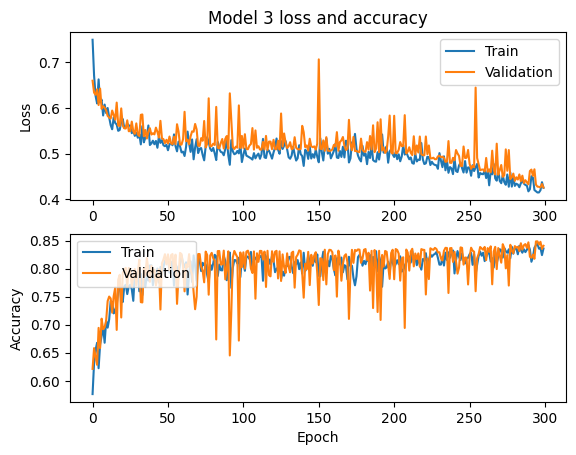

14/14 [==============================] - 1s 53ms/step - loss: 0.4256 - binary_accuracy: 0.8410
model1 validation test accuracy: 0.8409545421600342
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 z_global (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 y_local (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 x_size (InputLayer)         [(None, 1)]                  0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]   

In [8]:
plotModelHistory(history1,3)
test_loss, test_acc = model1.evaluate(validationODG)
print("model1 validation test accuracy: "+str(test_acc))
model1.summary()

In [ ]:
saveModels = False;
if saveModels:
    filepath = "./DanielModels/ASIC50EpochsFullDatasetBatch1024.keras"
    model1.save(filepath)

In [ ]:
#from Eric's github
def build_quantized_mlp_model(weight_bits=4, weight_integer_bits=0, weight_alpha=1,
                              activation_bits=8, activation_integer_bits=0):
    """
    Build a quantized MLP model for binary classification following the Model1 architecture.
    
    Architecture:
    - Input: 4 features (z_global, x_size, y_size, y_local)
    - Hidden layers: 17 -> 20 -> 9 -> 16 -> 8
    - Output: 1 unit with smooth_sigmoid activation
    
    Args:
        weight_bits: total bits for quantized_bits
        weight_integer_bits: integer bits for quantized_bits  
        weight_alpha: alpha for quantized_bits
        activation_bits: total bits for quantized_relu
        activation_integer_bits: integer bits for quantized_relu
    """

    
    weight_quantizer = quantized_bits(weight_bits, weight_integer_bits, weight_alpha)
    bias_quantizer = quantized_bits(weight_bits, weight_integer_bits, weight_alpha)
    activation_quantizer = quantized_relu(activation_bits, activation_integer_bits)
    final_activation_quantizer = quantized_argmax()
    
    # Define inputs
    input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
    input2 = tf.keras.layers.Input(shape=(1,), name="y_local")
    input3 = tf.keras.layers.Input(shape=(1,), name="x_size")
    input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
    
    # Concatenate all inputs
    x =  tf.keras.layers.Concatenate()([input1, input2, input3, input4])
    
    # Layer 1
    x = QDense( #QDenseBatchnorm
        58,
        kernel_quantizer=weight_quantizer,
        bias_quantizer=bias_quantizer,
        name="dense1"
    )(x)
    x = QActivation(
        activation=activation_quantizer,
        name="q_relu1"
    )(x)
    
    # Layer 2
    x = QDense(
        3,
        kernel_quantizer=weight_quantizer,
        bias_quantizer=bias_quantizer,
        name="dense2"
    )(x)
    x = QActivation(
        activation=activation_quantizer,
        name="q_relu2"
    )(x)


    
    # Output layer
    x = QDense(
        1,
        kernel_quantizer=weight_quantizer,
        bias_quantizer=bias_quantizer,
        name="output_dense"
    )(x)
    output = QActivation("smooth_sigmoid", name="output")(x)
    
    model = Model(inputs=[input1, input2, input3, input4], outputs=output, name="quantized_mlp_model")
    return model

In [2]:
def CreateQModel(shape=16, model_file=None):
    # Define inputs
    input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
    input2 = tf.keras.layers.Input(shape=(1,), name="y_local")
    input3 = tf.keras.layers.Input(shape=(1,), name="x_size")
    input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
    inputList = [input1, input2, input3, input4]
    inputList = [input2,input4]
    
    # Concatenate all inputs
    x =  tf.keras.layers.Concatenate()(inputList)
    # x = x_in = Input(shape, name="input1")
    x = QDenseBatchnorm(58,
      kernel_quantizer=quantized_bits(4,0,alpha=1),
      bias_quantizer=quantized_bits(4,0,alpha=1),
      name="dense1")(x)
    x = QActivation("quantized_relu(8,0)", name="relu1")(x)
    #Fermilab's output layer, not right for our dataset currently
    # x = QDense(3,
    #     kernel_quantizer=quantized_bits(4,0,alpha=1),
    #     bias_quantizer=quantized_bits(4,0,alpha=1),
    #     name="dense2")(x)
    # x = QActivation("linear", name="linear")(x)

    #Eric's Output layer
    x = QDense(
        1,
        kernel_quantizer=quantized_bits(4,0,alpha=1),
        bias_quantizer=quantized_bits(4,0,alpha=1),
        name="output_dense"
    )(x)
    output = QActivation("smooth_sigmoid", name="output")(x)
    model = tf.keras.Model(inputs=inputList, outputs=x)

    model.summary()
    return model
quantizedModel = CreateQModel()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 y_local (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]                 0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14)                   0         ['y_local[0][0]',             
                                                                     'y_profile[0][0]']           
                                                                                                  
 dense1 (QDenseBatchnorm)    (None, 58)                   1103      ['concatenate[0][0]']     

In [22]:
quantizedModel.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# callbacks=[]
# learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
# callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
callbacks=[]
historyQ = quantizedModel.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=20)

Epoch 1/20


/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_size', 'z_global', 'x_profile', 'cluster'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


157/157 [==============================] - 15s 90ms/step - loss: 2.2724 - binary_accuracy: 0.6384 - val_loss: 0.4959 - val_binary_accuracy: 0.6932
Epoch 2/20
157/157 [==============================] - 13s 84ms/step - loss: 0.5060 - binary_accuracy: 0.7208 - val_loss: 0.4577 - val_binary_accuracy: 0.7313
Epoch 3/20
157/157 [==============================] - 13s 83ms/step - loss: 0.4463 - binary_accuracy: 0.7392 - val_loss: 0.4275 - val_binary_accuracy: 0.7624
Epoch 4/20
157/157 [==============================] - 13s 83ms/step - loss: 0.4460 - binary_accuracy: 0.7484 - val_loss: 0.4393 - val_binary_accuracy: 0.7666
Epoch 5/20
157/157 [==============================] - 13s 83ms/step - loss: 0.4465 - binary_accuracy: 0.7499 - val_loss: 0.4535 - val_binary_accuracy: 0.7343
Epoch 6/20
157/157 [==============================] - 13s 83ms/step - loss: 0.4438 - binary_accuracy: 0.7482 - val_loss: 0.4339 - val_binary_accuracy: 0.7539
Epoch 7/20
157/157 [==============================] - 13s 82ms/

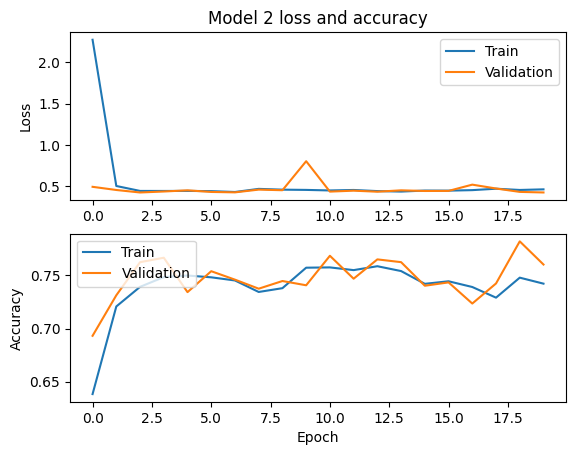

In [23]:
plotModelHistory(historyQ,2)

In [ ]:
if False:
    quantizedModel.save("sillyQuantizedModel.h5")

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# quantizedModel = tf.keras.models.load_model("sillyQuantizedModel.h5")

ValueError: Unknown layer: 'QDenseBatchnorm'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

Interpreting Model
Topology:
Layer name: y_local, layer type: InputLayer, input shapes: [[None, 1]], output shape: [None, 1]
Layer name: y_profile, layer type: InputLayer, input shapes: [[None, 13]], output shape: [None, 13]
Layer name: concatenate, layer type: Concatenate, input shapes: [[None, 1], [None, 13]], output shape: [None, 14]
Layer name: dense1, layer type: QDenseBatchnorm, input shapes: [[None, 14]], output shape: [None, 58]
Layer name: relu1, layer type: Activation, input shapes: [[None, 58]], output shape: [None, 58]
Layer name: output_dense, layer type: QDense, input shapes: [[None, 58]], output shape: [None, 1]
Interpreting Model
Topology:
Layer name: y_local, layer type: InputLayer, input shapes: [[None, 1]], output shape: [None, 1]
Layer name: y_profile, layer type: InputLayer, input shapes: [[None, 13]], output shape: [None, 13]
Layer name: concatenate, layer type: Concatenate, input shapes: [[None, 1], [None, 13]], output shape: [None, 14]
Layer name: dense1, layer 

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


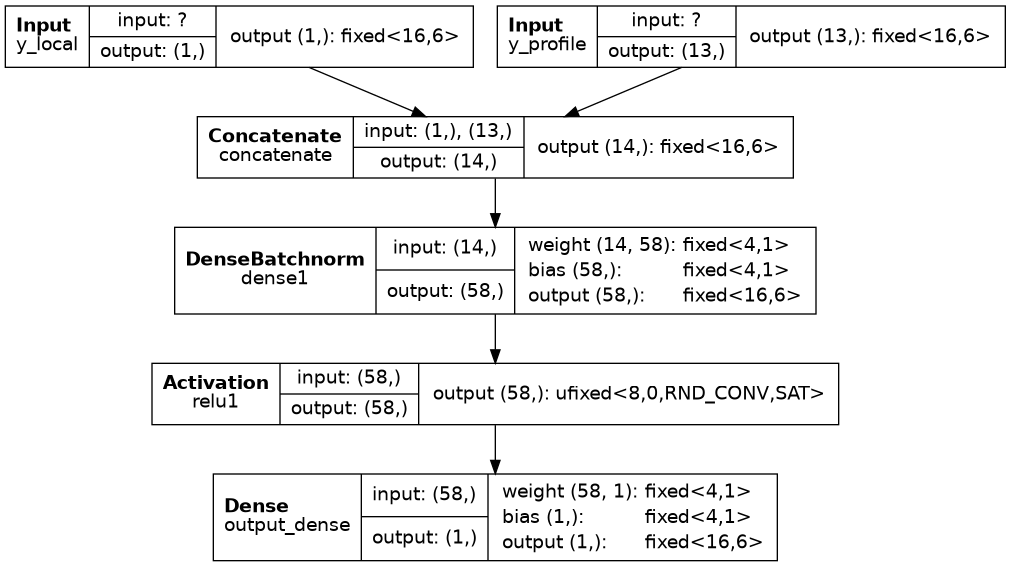

In [3]:
config = hls4ml.utils.config_from_keras_model(quantizedModel, granularity='name')
# Convert to an hls model
output_dir = "./hlsTmp"
hls_model = hls4ml.converters.convert_from_keras_model(quantizedModel, hls_config=config, output_dir=output_dir)
hls_model.write()


hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)



In [ ]:
# hls_model = hls4ml.converters.load_saved_model("./hlsTmp")

AttributeError: module 'hls4ml.converters' has no attribute 'load_saved_model'

In [4]:
os.system('source /code/Xilinx_2024.1/Vitis_HLS/2024.1/settings64.sh')
# os.system('echo "hellow"')
os.system('export PATH=/code/Xilinx_2024.1/Vitis_HLS/2024.1/bin:$PATH')
os.system('echo $PATH')
hls_model.build(csim=False)



/home/dabadjiev/miniconda3/envs/miscGithubEnviro/bin:/home/dabadjiev/.vscode-server/cli/servers/Stable-0f0d87fa9e96c856c5212fc86db137ac0d783365/server/bin/remote-cli:/home/dabadjiev/miniconda3/envs/miscGithubEnviro/bin:/home/dabadjiev/miniconda3/condabin:/home/dabadjiev/.local/bin:/home/dabadjiev/bin:/usr/share/Modules/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/code/Siemens_EDA/Catapult_Synthesis_2023.2_2-1075281/Mgc_home/bin:/code/Siemens_EDA/Catapult_Synthesis_2023.2_2-1075281/Mgc_home/bin


Exception: Vivado HLS installation not found. Make sure "vivado_hls" is on PATH.